### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Yue Wu
*   Your **student number**: 1000299456



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [1]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [2]:
countries = pd.read_csv(countries_list_url, header=None)[0].tolist()
print(countries[0:5])

raw_data.head(100)

['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra']


,entity,code,year,population_historical
0,Afghanistan,AFG,-10000,14737
1,Afghanistan,AFG,-9000,20405
2,Afghanistan,AFG,-8000,28253
3,Afghanistan,AFG,-7000,39120
4,Afghanistan,AFG,-6000,54166
...,...,...,...,...
95,Afghanistan,AFG,1858,3887081
96,Afghanistan,AFG,1859,3904521
97,Afghanistan,AFG,1860,3922032
98,Afghanistan,AFG,1861,3939616


In [3]:
df = raw_data.loc[ (raw_data['year'] >= 1901) & (raw_data['year']<=2023) ].drop(columns = ['code']).reset_index(drop= True).rename(columns={'entity':'country'})
df = df[df['country'].isin(countries)].pivot(
    index = 'country',
    columns = 'year',
    values = 'population_historical'
).dropna()

print('raw data shape: ',raw_data.shape)
print('processed shape', df.shape)
df.head(15)


raw data shape:  (58824, 4)
processed shape (196, 123)


year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0
Antigua and Barbuda,34307.0,34017.0,33707.0,33399.0,33095.0,32793.0,32493.0,32197.0,31919.0,31659.0,...,88784.0,89421.0,89980.0,90483.0,90942.0,91377.0,91864.0,92358.0,92850.0,93331.0
Argentina,4855502.0,5036658.0,5229108.0,5428911.0,5636349.0,5851713.0,6075305.0,6307441.0,6532092.0,6748544.0,...,43024071.0,43477011.0,43900312.0,44288898.0,44654876.0,44973469.0,45191960.0,45312282.0,45407904.0,45538402.0
Armenia,871245.0,879338.0,887506.0,895750.0,904070.0,912468.0,920944.0,929498.0,938132.0,946846.0,...,2922433.0,2921179.0,2918796.0,2914966.0,2909971.0,2903975.0,2890893.0,2870339.0,2880880.0,2943398.0
Australia,3755013.0,3815541.0,3874858.0,3935097.0,3996273.0,4058399.0,4121490.0,4185562.0,4254685.0,4329018.0,...,23595599.0,23947997.0,24329963.0,24731044.0,25119700.0,25482714.0,25743787.0,25956417.0,26200987.0,26451126.0


### Tasks


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

### Part 1-3

In [32]:
import Levenshtein

first_name = "yue"

def find_closest(country_list, word, n=2):
    '''accepts a list of countries and a word and return the countries list and the distance'''
    dist = []
    for c in country_list:
        distance = Levenshtein.distance(c.lower(), word.lower())
        dist.append((c, distance))

        dist.sort(key = lambda x: x[1]) # use a lambda function to sort by the element of a tuple
        
    return [country for country, distance in dist[:n]], dist[:n]

candidates, res = find_closest(countries, first_name)

print(candidates, "\n", res)

['Niue', 'Cuba'] 
 [('Niue', 2), ('Cuba', 3)]


### Part 1-1 

In [37]:
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler

def timeseries_plot(dataframe, country_list, word):
    '''
    takes a dataframe, a list of countries, and a word to match the country list against. if word is None, no distance based matching will be done.
    '''
    valid_countries = dataframe.index.intersection(country_list) # match the country list with the country index on the dataframe
    
    if word != None:
        match_list, res = find_closest(valid_countries, word)      # two closest countries based on valid countries 
        print('Countries with the closest distance: ', match_list)

        n_countries = len(match_list)
        n_cols = 2
    else:
        match_list = valid_countries
    
    n_countries = len(match_list)
    n_cols = 2
    
    fig, axes = plt.subplots(
        n_countries//n_cols + 1, 
        n_cols,
        figsize = (10, n_countries//n_cols * 6)
    )
    axes = axes.flatten()

    for i in range(len(match_list)):
        c = match_list[i]
        
        # get row of population
        row = dataframe.loc[c]

        axes[i].plot(dataframe.columns, # years 
                      row,     # population
                      label= c)
        
        axes[i].set_title(c) # name the plot with the country
        axes[i].set_xlabel("Year")
        axes[i].set_ylabel("Population")

    # remove unused plots
    for i in range(n_countries, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()


### Part 1-2

In [5]:
scaler = StandardScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(df), index=df.index, columns=df.columns) # column-wise scaling by default 

print('standard deviation of the scaled data: ',df_scaled[2021].std(), '\nmean of the scaled data: ', df_scaled[2021].mean())

df_scaled.head(10)


standard deviation of the scaled data:  1.002560823655206 
mean of the scaled data:  0.0


year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,-0.100165,-0.100047,-0.099763,-0.099484,-0.099208,-0.098936,-0.098672,-0.098414,-0.096248,-0.092059,...,-0.034059,-0.029623,-0.026427,-0.022423,-0.017953,-0.013063,-0.007375,-0.003373,-0.001763,0.001713
Albania,-0.210133,-0.210609,-0.211095,-0.211588,-0.212088,-0.212596,-0.213114,-0.213642,-0.214023,-0.214260,...,-0.246648,-0.247677,-0.248635,-0.249513,-0.250503,-0.251641,-0.252834,-0.254159,-0.255592,-0.257056
Algeria,-0.099160,-0.098461,-0.097624,-0.096782,-0.095934,-0.095080,-0.094224,-0.093365,-0.092700,-0.092229,...,0.011552,0.013996,0.016545,0.019132,0.021633,0.024039,0.026348,0.028763,0.031174,0.033249
Andorra,-0.232726,-0.233281,-0.233835,-0.234396,-0.234965,-0.235540,-0.236126,-0.236721,-0.237152,-0.237421,...,-0.266777,-0.267602,-0.268379,-0.269074,-0.269870,-0.270801,-0.271785,-0.272866,-0.274068,-0.275342
Angola,-0.146728,-0.148310,-0.149959,-0.151601,-0.153239,-0.154871,-0.156500,-0.158127,-0.159538,-0.160733,...,-0.074116,-0.069620,-0.064978,-0.060195,-0.055368,-0.050451,-0.045471,-0.040285,-0.035004,-0.029793
Antigua and Barbuda,-0.231895,-0.232464,-0.233032,-0.233607,-0.234189,-0.234779,-0.235378,-0.235986,-0.236431,-0.236712,...,-0.266670,-0.267480,-0.268254,-0.268958,-0.269762,-0.270699,-0.271687,-0.272772,-0.273980,-0.275259
Argentina,-0.097251,-0.093544,-0.089626,-0.085573,-0.081381,-0.077048,-0.072569,-0.067942,-0.063468,-0.059168,...,0.038715,0.038369,0.037852,0.037136,0.036403,0.035493,0.034146,0.032484,0.030707,0.029058
Armenia,-0.208521,-0.208990,-0.209465,-0.209947,-0.210437,-0.210934,-0.211441,-0.211957,-0.212317,-0.212521,...,-0.246515,-0.247518,-0.248489,-0.249398,-0.250395,-0.251511,-0.252706,-0.254019,-0.255234,-0.256174
Australia,-0.127985,-0.127454,-0.127006,-0.126558,-0.126108,-0.125658,-0.125210,-0.124763,-0.124067,-0.123122,...,-0.099474,-0.099296,-0.098887,-0.098311,-0.097808,-0.097476,-0.097736,-0.098177,-0.098435,-0.098757


### Part 1-4

#### Plotting unscaled data

Countries with the closest distance:  ['Cuba', 'Yemen']


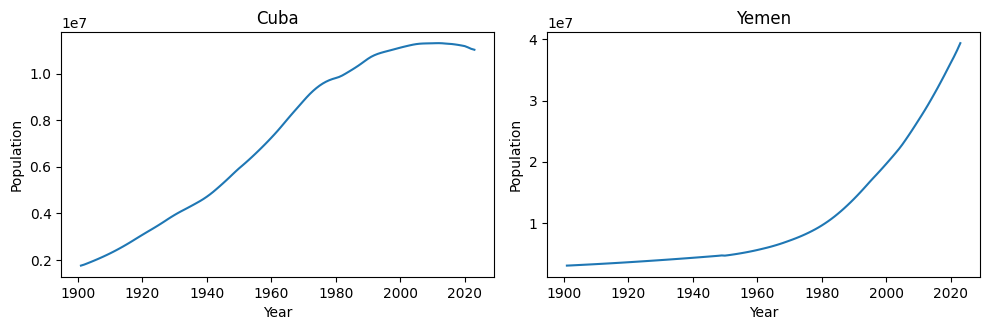

In [39]:
timeseries_plot(df, countries, first_name)

#### Plotting the scaled data

Countries with the closest distance:  ['Cuba', 'Yemen']


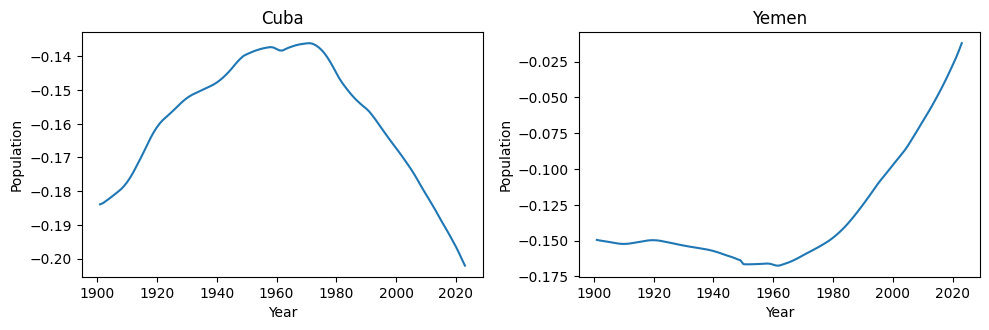

In [38]:
timeseries_plot(df_scaled, countries, first_name)

#### Plotting with unscaled and scaled data for new list of countries

Plotting with unscaled data: 


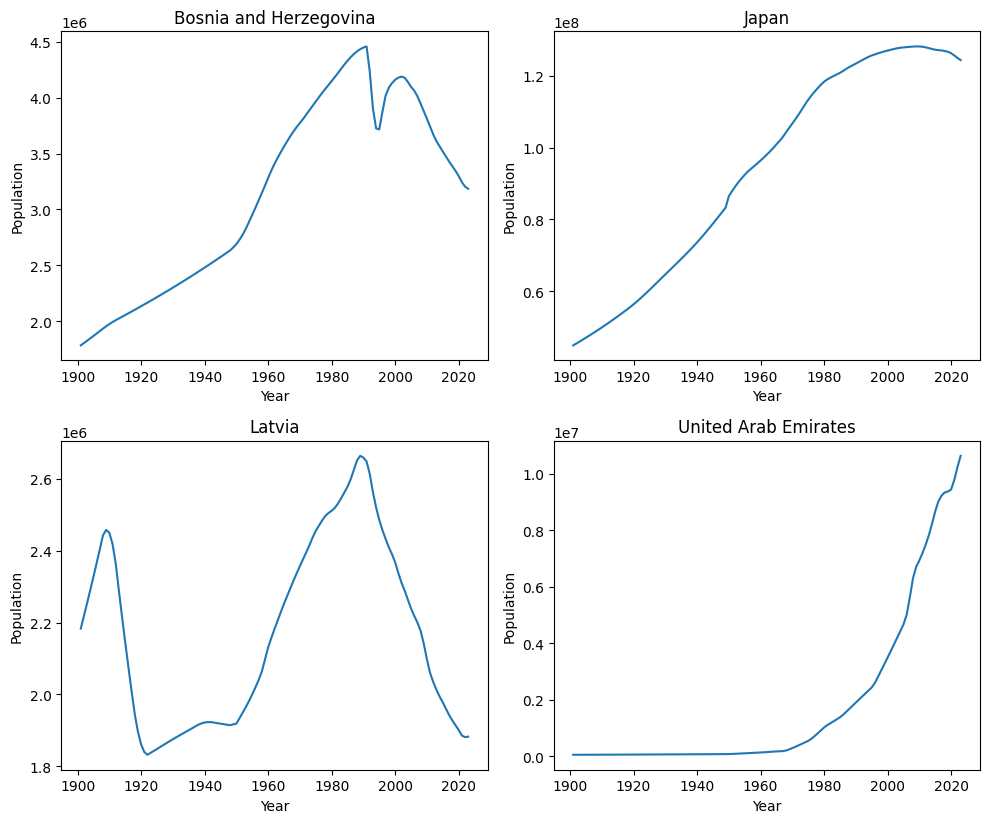

Plotting with scaled data: 


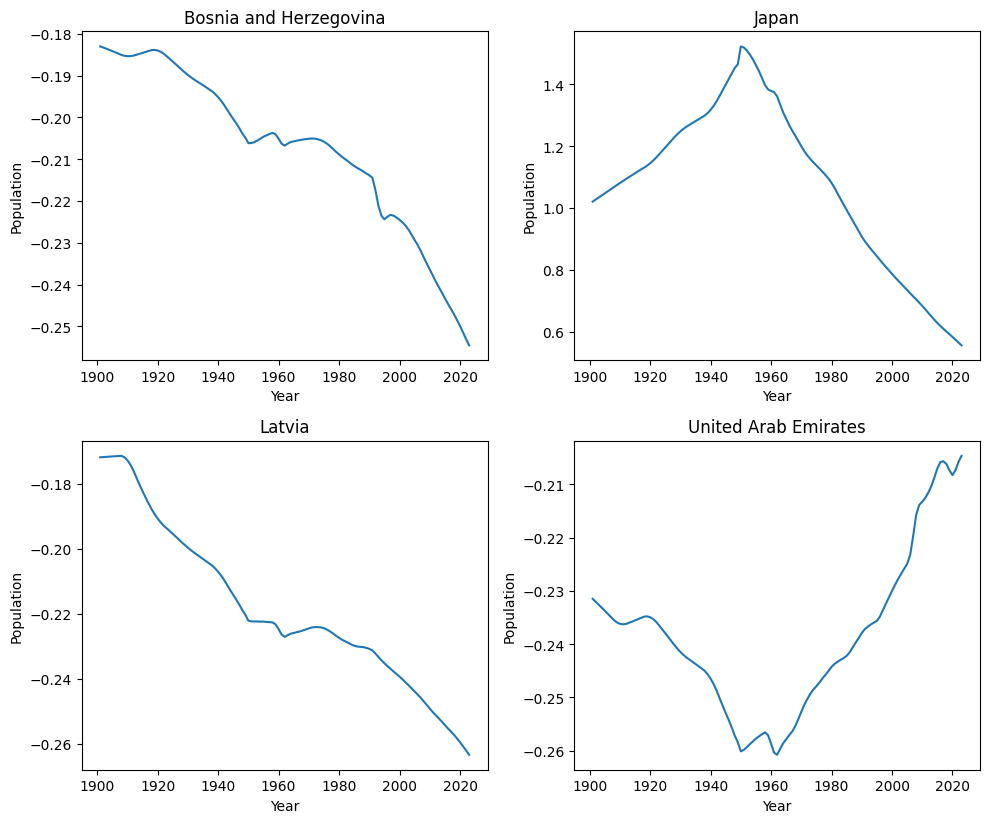

In [43]:
countries_2 = ['Japan', 'Bosnia and Herzegovina', 'Latvia', 'United Arab Emirates']
print('Plotting with unscaled data: ')
timeseries_plot(df, countries_2, word=None)
print('Plotting with scaled data: ')
timeseries_plot(df_scaled, countries_2, word=None)

#### Part 1-5

We plotted the population standardized across all available countries each year, against the year, for six countries: Cuba, Yemen, Bosnia and Herzegovina, Japan, Latvia, and United Arab Emirates. The visual trends in these standardized plots tell very different story than the plots with unscaled data. All countries except for Japan had negative scaled population. The scaled population for Cube grew until the 1960s and decreased after the 80s. Yemen saw a slow decrease from 1900 to 1960s and grew lineary since the 1960s to the end of the horizon. Bosnia and Herzegovina and Latvia both had a continuous drop from 1900 to 2020s and at a similar scale. And for United Arab Emirates, the scaled data dropped from 1900 to around 1960s and grew continuously afterwards. Lastly, Japan's scaled population grew from 1900 to around the 1950s and quickly decreased till the end of the horizon. 

Since we normalized the population by year, the scaled population is a comparison of population between the country and the population distribution of all countries in that year. A negative value means that the country has a population that is smaller than average population across all countries that year, and a positive value means the country has a population higher than the average population of all countries. Therefore, the trends illustrate changes in the relative population size of the country compared with other countries over time, rather than changes in absolute population or direct shares of the global population.